In [1]:
# ============================================================================
# CELL 1: Kaggle Environment Setup (UPDATED - NO INPUT())
# ============================================================================
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Detect Kaggle environment
IN_KAGGLE = os.path.exists('/kaggle/input')

print("=" * 70)
print("KAGGLE ENVIRONMENT CHECK")
print("=" * 70)

if IN_KAGGLE:
    print("✓ Running in Kaggle environment")
    
    # Kaggle paths
    INPUT_DIR = Path('/kaggle/input')
    WORKING_DIR = Path('/kaggle/working')
    OUTPUT_DIR = WORKING_DIR / 'outputs'
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    print(f"\nKaggle Directories:")
    print(f"  Input (read-only): {INPUT_DIR}")
    print(f"  Working (writable): {WORKING_DIR}")
    print(f"  Outputs: {OUTPUT_DIR}")
    
    # List available datasets
    print(f"\nAvailable datasets:")
    available_datasets = []
    if INPUT_DIR.exists():
        for dataset in INPUT_DIR. iterdir():
            print(f"  - {dataset.name}")
            available_datasets.append(dataset)
    
    # ============================================================
    # DATASET SELECTION (NO input() - edit manually if needed)
    # ============================================================
    
    if len(available_datasets) == 1:
        # Auto-select if only one dataset
        DATASET_ROOT = available_datasets[0]
        print(f"\n✓ Auto-selected:  {DATASET_ROOT.name}")
    
    elif len(available_datasets) > 1:
        # MANUALLY SPECIFY YOUR DATASET NAME HERE: 
        DATASET_NAME = "garbage-detection-asian"  # <-- EDIT THIS IF NEEDED
        
        DATASET_ROOT = INPUT_DIR / DATASET_NAME
        
        if not DATASET_ROOT.exists():
            print(f"\n⚠ Dataset '{DATASET_NAME}' not found!")
            print(f"Available:  {[d.name for d in available_datasets]}")
            raise Exception(f"Edit DATASET_NAME in Cell 1")
        
        print(f"\n✓ Using dataset:  {DATASET_ROOT.name}")
    
    else:
        raise Exception("No datasets found!  Add your dataset in Kaggle.")
    
else:
    print("⚠ Not running in Kaggle.  Using local paths.")
    DATASET_ROOT = Path('FYP/final_dataset')
    OUTPUT_DIR = Path('outputs')
    OUTPUT_DIR.mkdir(exist_ok=True)

print(f"\n✓ Dataset root: {DATASET_ROOT}")
print("=" * 70)

KAGGLE ENVIRONMENT CHECK
✓ Running in Kaggle environment

Kaggle Directories:
  Input (read-only): /kaggle/input
  Working (writable): /kaggle/working
  Outputs: /kaggle/working/outputs

Available datasets:
  - garbage-detection-asian

✓ Auto-selected:  garbage-detection-asian

✓ Dataset root: /kaggle/input/garbage-detection-asian


In [2]:
# CELL 2: Runtime & GPU Check
# ============================================================================
import torch
import subprocess

print("\n" + "=" * 70)
print("GPU & RUNTIME CHECK")
print("=" * 70)

cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    device_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"GPU Device: {device_name}")
    print(f"VRAM: {vram_gb:.2f} GB")
    
    # Batch size recommendations for Kaggle GPUs
    if 'P100' in device_name:
        recommended_batch = 32
        recommended_imgsz = 640
        print("✓ Detected P100 - Excellent for training!")
    elif 'T4' in device_name:
        recommended_batch = 16
        recommended_imgsz = 640
        print("✓ Detected T4 - Good for training!")
    else:
        recommended_batch = 16
        recommended_imgsz = 640
    
    print(f"\nRecommended settings:")
    print(f"  Batch size: {recommended_batch}")
    print(f"  Image size: {recommended_imgsz}")
else:
    print("⚠ No GPU detected!")
    recommended_batch = 8
    recommended_imgsz = 416

print("=" * 70)


GPU & RUNTIME CHECK
CUDA Available: True
GPU Device: Tesla P100-PCIE-16GB
VRAM: 15.89 GB
✓ Detected P100 - Excellent for training!

Recommended settings:
  Batch size: 32
  Image size: 640


In [3]:
# CELL 3: Install Dependencies
# ============================================================================
print("\nInstalling dependencies...")

!pip install -q -U ultralytics albumentations opencv-python-headless matplotlib seaborn pandas scikit-learn tqdm pycocotools onnx onnxruntime

print("✓ Dependencies installed")


Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.7/411.7 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigfram

In [4]:
# CELL 4: Imports & Reproducibility
# ============================================================================
import random
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
from datetime import datetime
from tqdm.auto import tqdm
import shutil

# Set seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

print("✓ Imports completed and seeds set")


✓ Imports completed and seeds set


In [5]:
# CELL 5: Dataset Configuration & Path Detection
# ============================================================================
CLASS_NAMES = [
    'Animal Waste',
    'Construction Waste',
    'Garbage Bag',
    'Glass',
    'Metal',
    'Organic',
    'Paper',
    'Plastic',
    'waste'
]

NUM_CLASSES = len(CLASS_NAMES)

# Auto-detect dataset structure
print("\n" + "=" * 70)
print("DATASET PATH DETECTION")
print("=" * 70)

def find_dataset_paths(root):
    """Auto-detect train/val/test paths in various structures."""
    possible_structures = [
        # Structure 1: root/train/images, root/valid/images
        {
            'train_img': root / 'train' / 'images',
            'train_lbl': root / 'train' / 'labels',
            'val_img': root / 'valid' / 'images',
            'val_lbl': root / 'valid' / 'labels',
            'test_img': root / 'test' / 'images',
            'test_lbl': root / 'test' / 'labels',
        },
        # Structure 2: root/images/train, root/labels/train
        {
            'train_img': root / 'images' / 'train',
            'train_lbl': root / 'labels' / 'train',
            'val_img': root / 'images' / 'val',
            'val_lbl': root / 'labels' / 'val',
            'test_img': root / 'images' / 'test',
            'test_lbl': root / 'labels' / 'test',
        },
        # Structure 3: Flat structure
        {
            'train_img': root / 'train',
            'train_lbl': root / 'train',
            'val_img': root / 'val',
            'val_lbl': root / 'val',
            'test_img': root / 'test',
            'test_lbl': root / 'test',
        },
    ]
    
    for structure in possible_structures:
        if structure['train_img'].exists() and structure['train_lbl'].exists():
            return structure
    
    return None

paths = find_dataset_paths(DATASET_ROOT)

if paths is None:
    print(f"⚠ Auto-detection failed. Please check dataset structure.")
    print(f"\nExpected structure:")
    print(f"  {DATASET_ROOT}/")
    print(f"    train/")
    print(f"      images/")
    print(f"      labels/")
    print(f"    valid/")
    print(f"      images/")
    print(f"      labels/")
    raise Exception("Dataset structure not recognized")

TRAIN_IMAGES = paths['train_img']
TRAIN_LABELS = paths['train_lbl']
VAL_IMAGES = paths['val_img']
VAL_LABELS = paths['val_lbl']
TEST_IMAGES = paths['test_img']
TEST_LABELS = paths['test_lbl']

print(f"✓ Dataset paths detected:")
print(f"  Train images: {TRAIN_IMAGES}")
print(f"  Val images: {VAL_IMAGES}")
print(f"  Test images: {TEST_IMAGES}")


DATASET PATH DETECTION
✓ Dataset paths detected:
  Train images: /kaggle/input/garbage-detection-asian/train/images
  Val images: /kaggle/input/garbage-detection-asian/valid/images
  Test images: /kaggle/input/garbage-detection-asian/test/images


In [6]:
# CELL 6: Helper Functions
# ============================================================================
def count_images_and_labels(images_dir, labels_dir):
    """Count images and labels."""
    if not images_dir.exists():
        return 0, 0, []
    
    image_files = (
        list(images_dir.glob('*.jpg')) +
        list(images_dir.glob('*.png')) +
        list(images_dir.glob('*.jpeg'))
    )
    num_images = len(image_files)
    
    labels_with_images = 0
    missing_labels = []
    
    for img_path in image_files:
        label_path = labels_dir / f"{img_path.stem}.txt"
        if label_path.exists():
            labels_with_images += 1
        else:
            missing_labels.append(img_path.name)
    
    return num_images, labels_with_images, missing_labels

def get_class_distribution(labels_dir):
    """Get class distribution."""
    if not labels_dir.exists():
        return np.zeros(NUM_CLASSES)
    
    class_counts = np.zeros(NUM_CLASSES)
    label_files = list(labels_dir.glob('*.txt'))
    
    for label_file in label_files:
        try:
            with open(label_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        class_id = int(parts[0])
                        if 0 <= class_id < NUM_CLASSES:
                            class_counts[class_id] += 1
        except:
            continue
    
    return class_counts

def visualize_image_with_boxes(img_path, label_path, class_names, ax=None):
    """Visualize image with boxes."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    if label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])
                    
                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)
                    
                    color = tuple(np.random.randint(0, 255, 3).tolist())
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    
                    label = class_names[class_id] if class_id < len(class_names) else f"Class {class_id}"
                    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_path.name)
    
    return ax

print("✓ Helper functions defined")

✓ Helper functions defined


In [7]:
# CELL 7: Dataset Inspection
# ============================================================================
print("\n" + "=" * 70)
print("DATASET INSPECTION")
print("=" * 70)

splits = {
    'train': (TRAIN_IMAGES, TRAIN_LABELS),
    'val': (VAL_IMAGES, VAL_LABELS),
    'test': (TEST_IMAGES, TEST_LABELS)
}

for split_name, (img_dir, lbl_dir) in splits.items():
    num_imgs, num_lbls, missing = count_images_and_labels(img_dir, lbl_dir)
    print(f"\n{split_name.upper()} Split:")
    print(f"  Images: {num_imgs}")
    print(f"  Labels: {num_lbls}")
    
    if missing:
        print(f"  ⚠ {len(missing)} images missing labels")

# Class distribution
train_dist = get_class_distribution(TRAIN_LABELS)
val_dist = get_class_distribution(VAL_LABELS)
test_dist = get_class_distribution(TEST_LABELS)

print("\n" + "=" * 70)
print("CLASS DISTRIBUTION")
print("=" * 70)
print(f"\n{'Class':<25} {'Train':<10} {'Val':<10} {'Test':<10}")
print("-" * 55)
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<25} {int(train_dist[i]):<10} {int(val_dist[i]):<10} {int(test_dist[i]):<10}")

# Check imbalance
max_count = train_dist.max()
min_count = train_dist[train_dist > 0].min() if (train_dist > 0).any() else 1
imbalance_ratio = max_count / min_count

print(f"\n⚠ Imbalance ratio: {imbalance_ratio:.1f}x")

if imbalance_ratio > 10:
    print("  SEVERE imbalance - strongly recommend balanced dataset")
elif imbalance_ratio > 5:
    print("  MODERATE imbalance - consider balanced dataset")
else:
    print("  MILD imbalance - default training should work")


DATASET INSPECTION

TRAIN Split:
  Images: 1263
  Labels: 1263

VAL Split:
  Images: 350
  Labels: 350

TEST Split:
  Images: 177
  Labels: 177

CLASS DISTRIBUTION

Class                     Train      Val        Test      
-------------------------------------------------------
Animal Waste              489        107        39        
Construction Waste        834        438        103       
Garbage Bag               672        138        77        
Glass                     1008       189        247       
Metal                     882        266        107       
Organic                   933        176        69        
Paper                     599        122        71        
Plastic                   707        125        37        
waste                     5797       1525       1082      

⚠ Imbalance ratio: 11.9x
  SEVERE imbalance - strongly recommend balanced dataset



SAMPLE VISUALIZATIONS


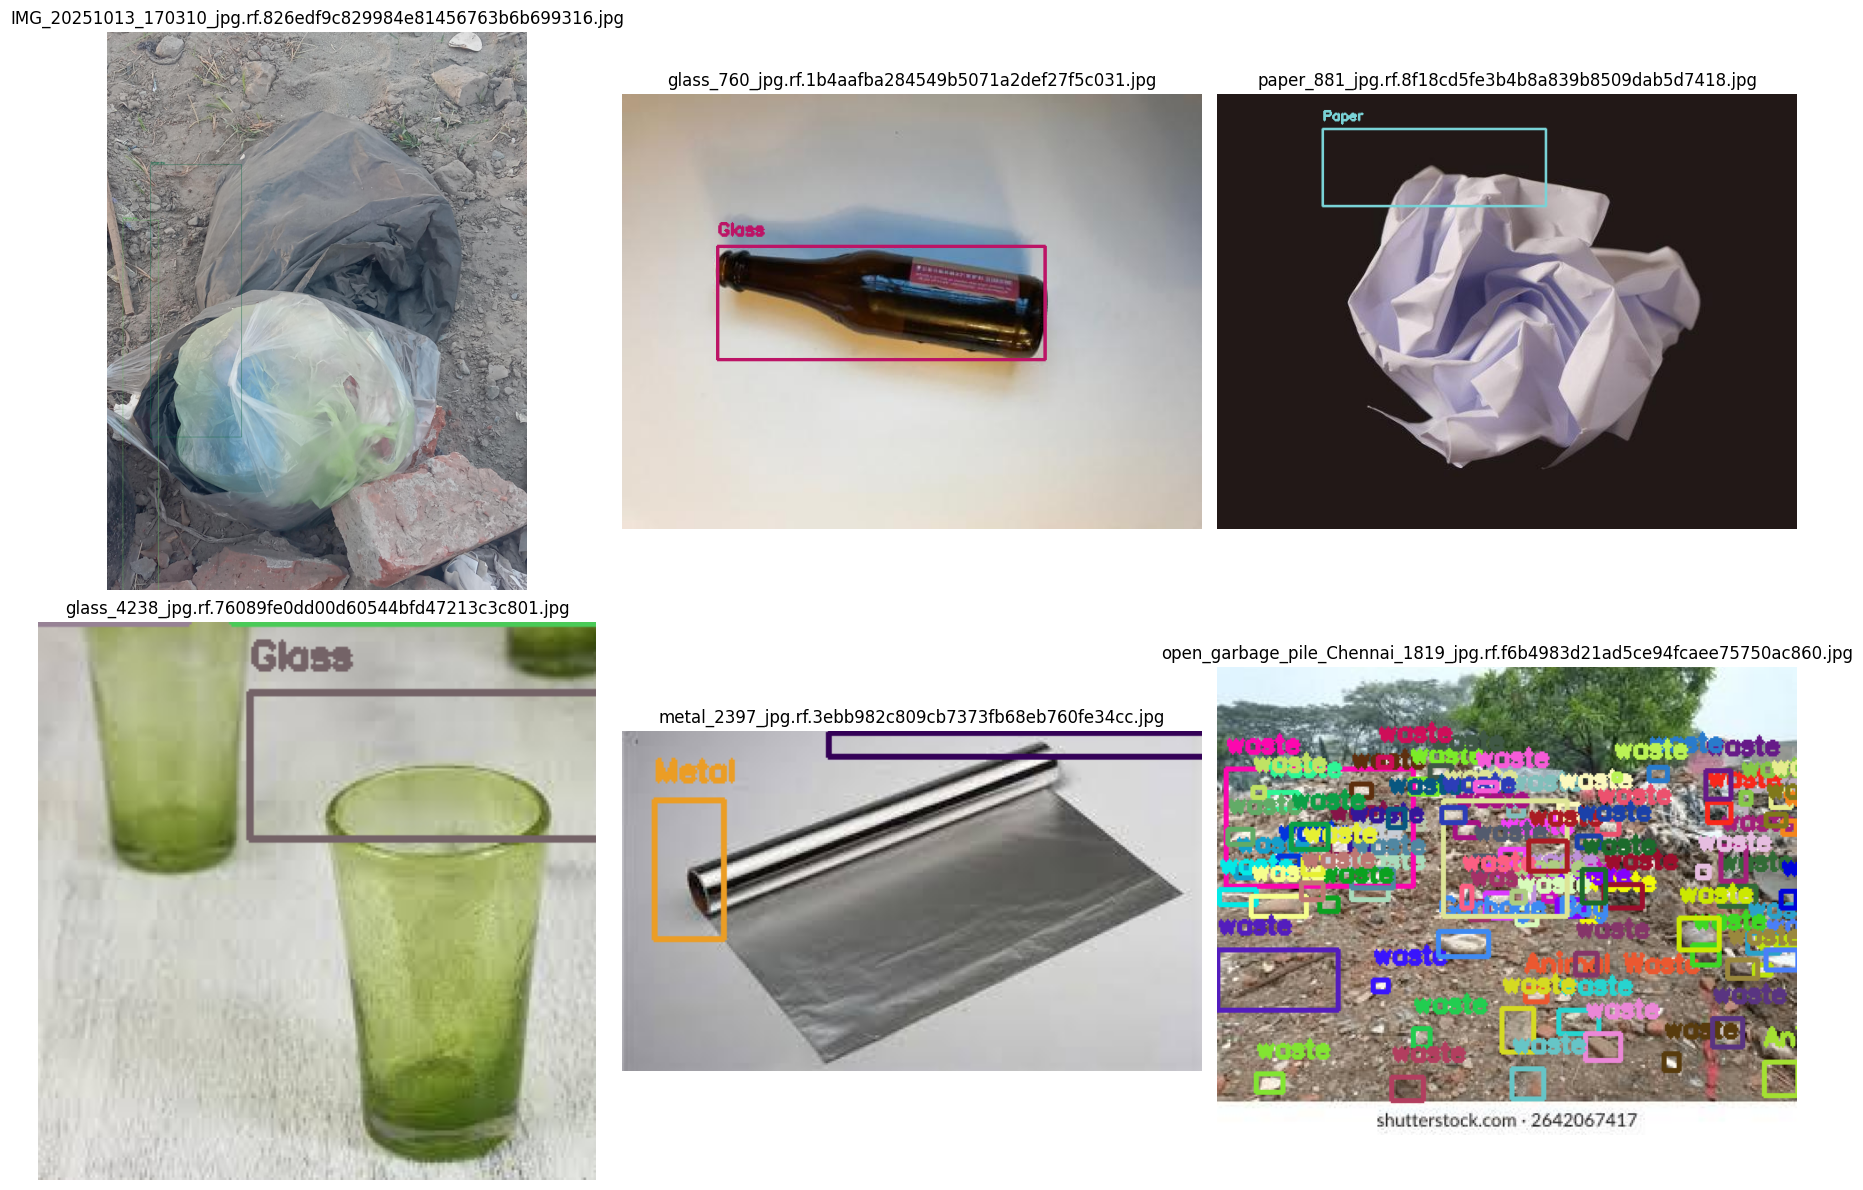

✓ Saved to: /kaggle/working/outputs/dataset_samples.png


In [8]:
# CELL 8: Visualize Samples (Save to Output)
# ============================================================================
print("\n" + "=" * 70)
print("SAMPLE VISUALIZATIONS")
print("=" * 70)

train_images = list(TRAIN_IMAGES.glob('*.jpg')) + list(TRAIN_IMAGES.glob('*.png'))
if len(train_images) >= 6:
    sample_images = random.sample(train_images, 6)
else:
    sample_images = train_images[:min(6, len(train_images))]

if sample_images:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, img_path in enumerate(sample_images):
        label_path = TRAIN_LABELS / f"{img_path.stem}.txt"
        visualize_image_with_boxes(img_path, label_path, CLASS_NAMES, axes[idx])
    
    plt.tight_layout()
    
    # Save to output directory
    viz_path = OUTPUT_DIR / 'dataset_samples.png'
    plt.savefig(viz_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved to: {viz_path}")

In [9]:
# CELL 9: Create Dataset YAML (in /kaggle/working)
# ============================================================================
print("\n" + "=" * 70)
print("CREATING DATASET YAML")
print("=" * 70)

# Create YAML in working directory (writable in Kaggle)
yaml_content = f"""# NEAT NOW Waste Detection Dataset
# Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

train: {TRAIN_IMAGES}
val: {VAL_IMAGES}
test: {TEST_IMAGES}

nc: {NUM_CLASSES}
names:
"""

for name in CLASS_NAMES:
    yaml_content += f"  - '{name}'\n"

yaml_path = WORKING_DIR / 'neatnow_waste.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"✓ YAML created at: {yaml_path}")


CREATING DATASET YAML
✓ YAML created at: /kaggle/working/neatnow_waste.yaml


In [10]:
# CELL 10: Training Configuration
# ============================================================================
print("\n" + "=" * 70)
print("TRAINING CONFIGURATION")
print("=" * 70)

from ultralytics import YOLO

# Model selection
if cuda_available and vram_gb >= 12:
    model_name = "yolov8m.pt"
    print(f"✓ Using YOLOv8-Medium")
else:
    model_name = "yolov8s.pt"
    print(f"✓ Using YOLOv8-Small")

model = YOLO(model_name)

# Hyperparameters (optimized for class imbalance)
HYPERPARAMS = {
    'data': str(yaml_path),
    'epochs': 100,
    'batch': recommended_batch,
    'imgsz': recommended_imgsz,
    'optimizer': 'SGD',
    'lr0': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'patience': 50,  # Don't stop early
    'save': True,
    'save_period': 10,
    'device': 0 if cuda_available else 'cpu',
    'workers': 4,  # Kaggle has limited CPU
    'project': str(WORKING_DIR / 'runs'),
    'name': 'train',
    'exist_ok': True,
    'seed': SEED,
    'deterministic': True,
    'amp': True,
    'cls': 2.0,  # Higher for imbalance
    'mosaic': 1.0,
    'mixup': 0.1,
    'cos_lr': True,
    'close_mosaic': 20,
}

print("\nKey Hyperparameters:")
for key in ['epochs', 'batch', 'imgsz', 'patience', 'cls', 'lr0']:
    print(f"  {key}: {HYPERPARAMS[key]}")

# Save config
config_path = OUTPUT_DIR / 'train_config.json'
with open(config_path, 'w') as f:
    json.dump({k: str(v) for k, v in HYPERPARAMS.items()}, f, indent=2)

print(f"\n✓ Config saved to: {config_path}")


TRAINING CONFIGURATION
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ Using YOLOv8-Medium

Key Hyperparameters:
  epochs: 100
  batch: 32
  imgsz: 640
  patience: 50
  cls: 2.0
  lr0: 0.01

✓ Config saved to: /kaggle/working/outputs/train_config.json


In [11]:
# CELL 11: TRAINING
# ============================================================================
print("\n" + "=" * 70)
print("STARTING TRAINING")
print("=" * 70)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n⏱ This will take 1-3 hours...")
print("=" * 70 + "\n")

try:
    results = model.train(**HYPERPARAMS)
    
    print("\n" + "=" * 70)
    print("TRAINING COMPLETED ✓")
    print("=" * 70)
    print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    
    # Copy trained model to output directory
    best_pt = WORKING_DIR / 'runs/train/weights/best.pt'
    if best_pt.exists():
        shutil.copy(best_pt, OUTPUT_DIR / 'best.pt')
        print(f"✓ Model saved to: {OUTPUT_DIR / 'best.pt'}")
    
except Exception as e:
    print(f"\n❌ Training failed: {e}")
    raise


STARTING TRAINING
Start time: 2026-01-01 07:27:52

⏱ This will take 1-3 hours...

Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=2.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/neatnow_waste.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, opt

In [12]:
# CELL 12: Evaluation & Metrics
# ============================================================================
print("\n" + "=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

# Load best model
best_model_path = WORKING_DIR / 'runs/train/weights/best.pt'
if best_model_path.exists():
    model = YOLO(str(best_model_path))
    print(f"✓ Loaded best model")
else:
    print("⚠ Using last checkpoint")
    model = YOLO(str(WORKING_DIR / 'runs/train/weights/last.pt'))

# Validation
val_results = model.val(data=str(yaml_path), split='val')

metrics = {
    'mAP@0.5': float(val_results.box.map50),
    'mAP@0.5:0.95': float(val_results.box.map),
    'Precision': float(val_results.box.mp),
    'Recall': float(val_results.box.mr),
}

print("\nValidation Metrics:")
print("-" * 70)
for metric_name, value in metrics.items():
    print(f"  {metric_name:<20}: {value:.4f}")

# Per-class AP
if hasattr(val_results.box, 'ap50'):
    print("\nPer-Class AP@0.5:")
    print("-" * 70)
    for name, ap in zip(CLASS_NAMES, val_results.box.ap50):
        print(f"  {name:<25}: {ap:.4f}")

# Save metrics
metrics_path = OUTPUT_DIR / 'validation_metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\n✓ Metrics saved to: {metrics_path}")


MODEL EVALUATION
✓ Loaded best model
Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 92 layers, 25,844,971 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 681.3±923.5 MB/s, size: 665.0 KB)
val: Scanning /kaggle/input/garbage-detection-asian/valid/labels... 350 images, 55 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 350/350 709.2it/s 0.5s
val: /kaggle/input/garbage-detection-asian/valid/images/glass_1864_jpg.rf.c39b3170d2015147c8d94d44a48c99ea.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/garbage-detection-asian/valid is not writable, cache not saved.
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1040, len(boxes) = 3085. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Ima

In [13]:
# CELL 13: Copy Training Artifacts to Output
# ============================================================================
print("\n" + "=" * 70)
print("SAVING OUTPUTS TO /kaggle/working/outputs")
print("=" * 70)

# Files to save
artifacts = {
    'confusion_matrix.png': WORKING_DIR / 'runs/train/confusion_matrix.png',
    'results.png': WORKING_DIR / 'runs/train/results.png',
    'F1_curve.png': WORKING_DIR / 'runs/train/F1_curve.png',
    'PR_curve.png': WORKING_DIR / 'runs/train/PR_curve.png',
    'best.pt': WORKING_DIR / 'runs/train/weights/best.pt',
    'last.pt': WORKING_DIR / 'runs/train/weights/last.pt',
}

print("\nCopying artifacts to output directory...")
saved_count = 0

for dest_name, source_path in artifacts.items():
    if source_path.exists():
        try:
            dest_path = OUTPUT_DIR / dest_name
            shutil.copy(source_path, dest_path)
            file_size = dest_path.stat().st_size / (1024 * 1024)
            print(f"  ✓ {dest_name:<30} ({file_size:.2f} MB)")
            saved_count += 1
        except Exception as e:
            print(f"  ✗ {dest_name:<30} - Error: {e}")
    else:
        print(f"  ⚠ {dest_name:<30} - Not found")

print(f"\n✓ Saved {saved_count}/{len(artifacts)} files")


SAVING OUTPUTS TO /kaggle/working/outputs

Copying artifacts to output directory...
  ✓ confusion_matrix.png           (0.24 MB)
  ✓ results.png                    (0.29 MB)
  ⚠ F1_curve.png                   - Not found
  ⚠ PR_curve.png                   - Not found
  ✓ best.pt                        (49.62 MB)
  ✓ last.pt                        (49.62 MB)

✓ Saved 4/6 files


In [14]:
# CELL 14: Export Models
# ============================================================================
print("\n" + "=" * 70)
print("EXPORTING MODELS")
print("=" * 70)

try:
    # Export to ONNX
    print("\nExporting to ONNX...")
    onnx_path = model.export(format='onnx', simplify=True)
    
    # Copy to output
    shutil.copy(onnx_path, OUTPUT_DIR / 'best.onnx')
    print(f"✓ ONNX saved to: {OUTPUT_DIR / 'best.onnx'}")
    
except Exception as e:
    print(f"⚠ ONNX export failed: {e}")



EXPORTING MODELS

Exporting to ONNX...
Ultralytics 8.3.245 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/runs/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 13, 8400) (49.6 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 261ms
Prepared 2 packages in 3.34s
Installed 2 packages in 104ms
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.81

requirements: AutoUpdate success ✅ 4.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.0 opset 22...
ONNX: slimming with onnxslim 0.1.81...
ONNX: export success ✅ 7.1s, saved as '/kaggle/working/runs/train/wei

In [15]:
# CELL 15: Create Final Summary
# ============================================================================
print("\n" + "=" * 70)
print("FINAL SUMMARY & DOWNLOAD INSTRUCTIONS")
print("=" * 70)

# Create comprehensive summary
summary = f"""
YOLOv8 Waste Detection Training Summary
========================================
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Platform: Kaggle

Dataset
-------
Train images: {int(train_dist.sum())}
Val images: {int(val_dist.sum())}
Test images: {int(test_dist.sum())}
Classes: {NUM_CLASSES}

Model
-----
Base model: {model_name}
Image size: {HYPERPARAMS['imgsz']}
Batch size: {HYPERPARAMS['batch']}
Epochs trained: {HYPERPARAMS['epochs']}

Performance
-----------
mAP@0.5: {metrics['mAP@0.5']:.4f}
mAP@0.5:0.95: {metrics['mAP@0.5:0.95']:.4f}
Precision: {metrics['Precision']:.4f}
Recall: {metrics['Recall']:.4f}

Output Files (in /kaggle/working/outputs/)
-------------------------------------------
✓ best.pt - Best model checkpoint
✓ best.onnx - ONNX export
✓ validation_metrics.json - Performance metrics
✓ train_config.json - Training configuration
✓ confusion_matrix.png - Confusion matrix
✓ results.png - Training curves
✓ dataset_samples.png - Sample visualizations

HOW TO DOWNLOAD OUTPUTS FROM KAGGLE
====================================
1. Click "Save Version" button (top right)
2. Choose "Save & Run All" 
3. Wait for notebook to finish
4. Go to "Output" tab (right sidebar)
5. Click download icon for individual files
   OR
6. Click "Download All" to get everything as ZIP

ALTERNATIVE: Commit as Dataset
===============================
1. Go to output tab
2. Click "+" button
3. "New Dataset" 
4. All outputs will be saved as a Kaggle dataset
5. Can be used in future notebooks

TO USE MODEL IN ANOTHER NOTEBOOK
=================================
# Add this notebook's output as data source
from ultralytics import YOLO
model = YOLO('/kaggle/input/[your-output-dataset]/best.pt')
results = model.predict('image.jpg')
"""

summary_path = OUTPUT_DIR / 'TRAINING_SUMMARY.txt'
with open(summary_path, 'w') as f:
    f.write(summary)

print(summary)
print(f"\n✓ Summary saved to: {summary_path}")

# List all output files
print("\n" + "=" * 70)
print("OUTPUT FILES")
print("=" * 70)
print(f"\nLocation: {OUTPUT_DIR}")
print("\nFiles:")

total_size = 0
for file in sorted(OUTPUT_DIR.glob('*')):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 * 1024)
        total_size += size_mb
        print(f"  • {file.name:<35} ({size_mb:.2f} MB)")

print(f"\nTotal size: {total_size:.2f} MB")

print("\n" + "=" * 70)
print("🎉 TRAINING COMPLETE! 🎉")
print("=" * 70)
print("\n✓ All outputs saved to /kaggle/working/outputs/")
print("✓ Ready to download or commit as dataset")
print("\n" + "=" * 70)


FINAL SUMMARY & DOWNLOAD INSTRUCTIONS

YOLOv8 Waste Detection Training Summary
Date: 2026-01-01 08:52:43
Platform: Kaggle

Dataset
-------
Train images: 11921
Val images: 3086
Test images: 1832
Classes: 9

Model
-----
Base model: yolov8m.pt
Image size: 640
Batch size: 32
Epochs trained: 100

Performance
-----------
mAP@0.5: 0.3301
mAP@0.5:0.95: 0.2519
Precision: 0.3939
Recall: 0.3451

Output Files (in /kaggle/working/outputs/)
-------------------------------------------
✓ best.pt - Best model checkpoint
✓ best.onnx - ONNX export
✓ validation_metrics.json - Performance metrics
✓ train_config.json - Training configuration
✓ confusion_matrix.png - Confusion matrix
✓ results.png - Training curves
✓ dataset_samples.png - Sample visualizations

HOW TO DOWNLOAD OUTPUTS FROM KAGGLE
1. Click "Save Version" button (top right)
2. Choose "Save & Run All" 
3. Wait for notebook to finish
4. Go to "Output" tab (right sidebar)
5. Click download icon for individual files
   OR
6. Click "Download All" 